In [3]:
import pandas as pd

df = pd.read_json("/home/pf4636/code/resnet/quantized_resnets/results/test_results.json")

table_results = df.drop(columns=["tput_mean", "tput_std", "n_seeds", "top1_std", "top5_std"]).copy()
table_results["lat_ms_std"] = table_results["lat_10k_std"]
table_results = table_results.drop(columns=["lat_10k_std", "lat_10k_bench"])
table_results




,backend,precision,input_bits,top1_mean,top5_mean,lat_ms_mean,lat_ms_std
0,pytorch,fp16,1,30.425532,59.858156,2.937262,1.244
1,pytorch,fp32,1,30.425532,59.716312,2.864540,1.244
2,pytorch,fp16,2,54.397163,80.425532,3.107899,1.244
3,pytorch,fp32,2,54.397163,80.425532,2.967031,1.244
4,pytorch,fp16,4,80.354610,96.241135,2.997534,1.244
5,pytorch,fp32,4,80.212766,96.241135,2.922133,1.244
6,pytorch,fp16,8,81.063830,96.737589,3.006366,1.244
7,pytorch,fp32,8,81.134752,96.666667,3.016726,1.244
8,tensorrt,fp16,1,30.496454,59.787234,0.497547,0.276
9,tensorrt,fp32,1,30.425532,59.787234,0.969025,0.136


In [4]:
table_results.to_csv("/home/pf4636/code/resnet/quantized_resnets/results/table_results.csv", index=False)
table_results.to_json("/home/pf4636/code/resnet/quantized_resnets/results/table_results.json", orient="records", indent=2)


In [5]:
df2 = pd.read_json("/home/pf4636/code/resnet/quantized_resnets/results/qat_test_results.json")

table_qat = df2.drop(columns=["throughput"]).copy()
table_qat = table_qat.sort_values("input_bits").reset_index(drop=True)

trt_int8 = table_results[table_results["precision"] == "int8"][
    ["precision", "input_bits", "top1_mean", "top5_mean", "lat_ms_mean", "lat_ms_std"]
].rename(columns={"top1_mean": "top1", "top5_mean": "top5",
                   "lat_ms_mean": "lat_ms", "lat_ms_std": "lat_std"})

table_qat = pd.concat([table_qat, trt_int8], ignore_index=True)
table_qat


,precision,input_bits,top1,top5,lat_ms,lat_std
0,qat_int8,1,61.914894,89.148936,8.929479,2.025922
1,qat_int8,2,75.319149,93.191489,9.770048,2.178919
2,qat_int8,4,80.212766,96.808511,8.500263,2.002171
3,qat_int8,8,80.425532,97.234043,8.941555,2.120668
4,int8,1,29.361702,60.212766,0.668675,0.276000
5,int8,2,53.971631,80.283688,0.707302,0.276000
6,int8,4,80.851064,96.312057,0.731996,0.276000
7,int8,8,80.709220,96.453901,0.672368,0.276000


In [6]:
table_qat.to_csv("/home/pf4636/code/resnet/quantized_resnets/results/test_results_qat.csv", index=False)
table_qat.to_json("/home/pf4636/code/resnet/quantized_resnets/results/test_results_qat.json", orient="records", indent=2)


# Plots


In [7]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

table_results = pd.read_csv("/home/pf4636/code/resnet/quantized_resnets/results/table_results.csv")
table_qat = pd.read_csv("/home/pf4636/code/resnet/quantized_resnets/results/test_results_qat.csv")

COLS = 2
eb_kw = dict(capsize=3, capthick=0.8, elinewidth=0.8, linewidth=0)

BIT_PALETTE = {
    1: "#002B45",   # Deep Navy
    2: "#009681",   # Teal Green
    4: "#239ED7",   # Bright Sky Blue
    8: "#8DB23E",   # Olive/Lime Green
}

PREC_PALETTE = {
    "fp32": "#002B45",   # Deep Navy
    "fp16": "#239ED7",   # Bright Sky Blue
    "fp8":  "#009681",   # Teal Green
    "int8": "#8DB23E",   # Olive/Lime Green
    "int4": "#0E4B75",   # Dark Prussian Blue
}

QAT_PALETTE = {
    "qat_int8": "#009681",   # Teal Green
    "int8":     "#0E4B75",   # Dark Prussian Blue
}

def make_figure(backend, n):
    nrows = math.ceil(n / COLS)
    fig, axes = plt.subplots(nrows, COLS, figsize=(4.5 * COLS, 3.8 * nrows),
                             constrained_layout=True, squeeze=False)
    fig.suptitle(backend, fontsize=12, fontweight="normal",
                 x=0.5, ha="center", y=1.04)
    fig.set_constrained_layout_pads(wspace=0.15, hspace=0.1)
    ax_flat = axes.flatten()
    for idx in range(n, len(ax_flat)):
        ax_flat[idx].set_visible(False)
    return ax_flat

def draw_bars(ax, grp, x_col, y_col, yerr_col, palette, ylabel="latency (ms)"):
    x_vals = grp[x_col].tolist()
    x_pos = np.arange(len(x_vals))
    for xi, (_, row) in enumerate(grp.iterrows()):
        key = row[x_col] if isinstance(row[x_col], str) else int(row[x_col])
        c = palette.get(key, "#7f7f7f")
        ax.bar(xi, row[y_col], color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.errorbar(xi, row[y_col], yerr=row[yerr_col],
                    fmt="none", ecolor=c, **eb_kw)
        ax.text(xi, row[y_col] * 0.02, f"{row[y_col]:.3f}",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_ylim(0, (grp[y_col] + grp[yerr_col]).max() * 1.25)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

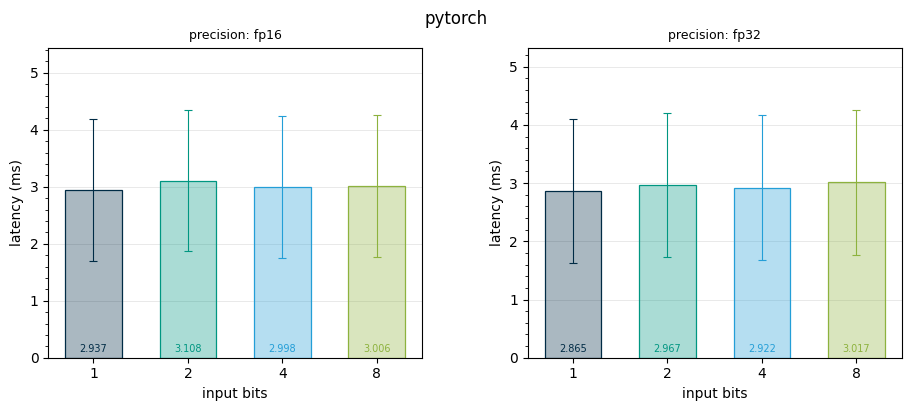

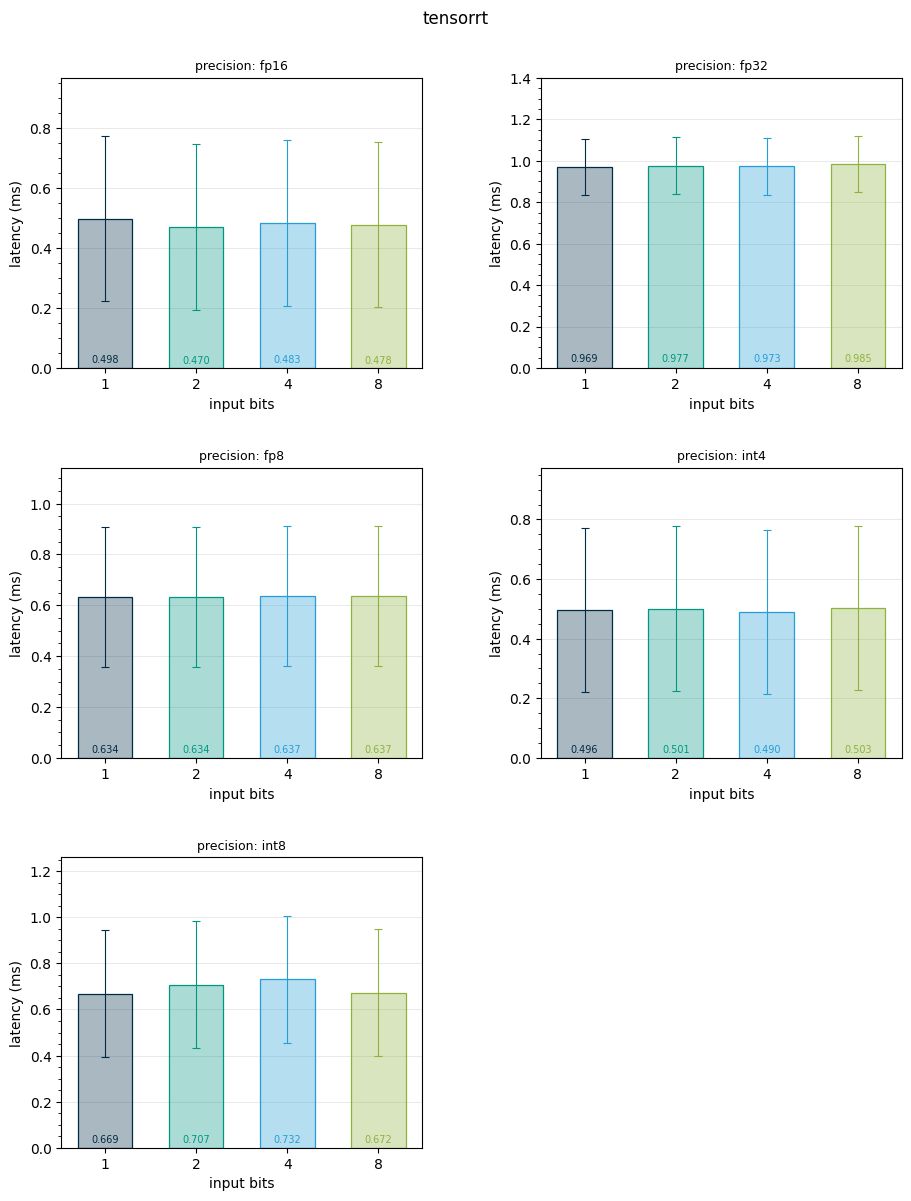

In [8]:
BACKENDS = ["pytorch", "tensorrt"]
for backend in BACKENDS:
    backend_data = table_results[table_results["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = (
            backend_data[backend_data["precision"] == prec]
            .sort_values("input_bits")
            .dropna(subset=["input_bits", "lat_ms_mean", "lat_ms_std"])
        )
        if grp.empty:
            ax.set_visible(False)
            continue

        grp = grp.copy()
        grp["input_bits"] = grp["input_bits"].astype(int)

        draw_bars(ax, grp, x_col="input_bits",
                  y_col="lat_ms_mean", yerr_col="lat_ms_std",
                  palette=BIT_PALETTE)
        ax.set_xlabel("input bits")
        ax.set_ylabel("latency (ms)")
        ax.set_title(f"precision: {prec}", fontsize=9)

    plt.show()


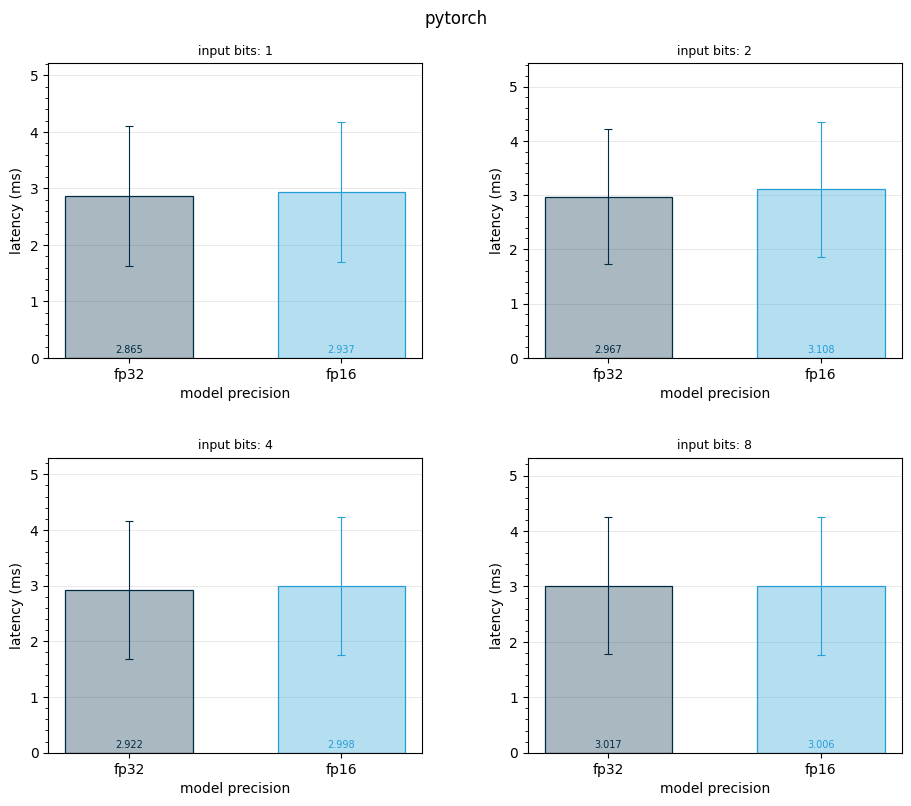

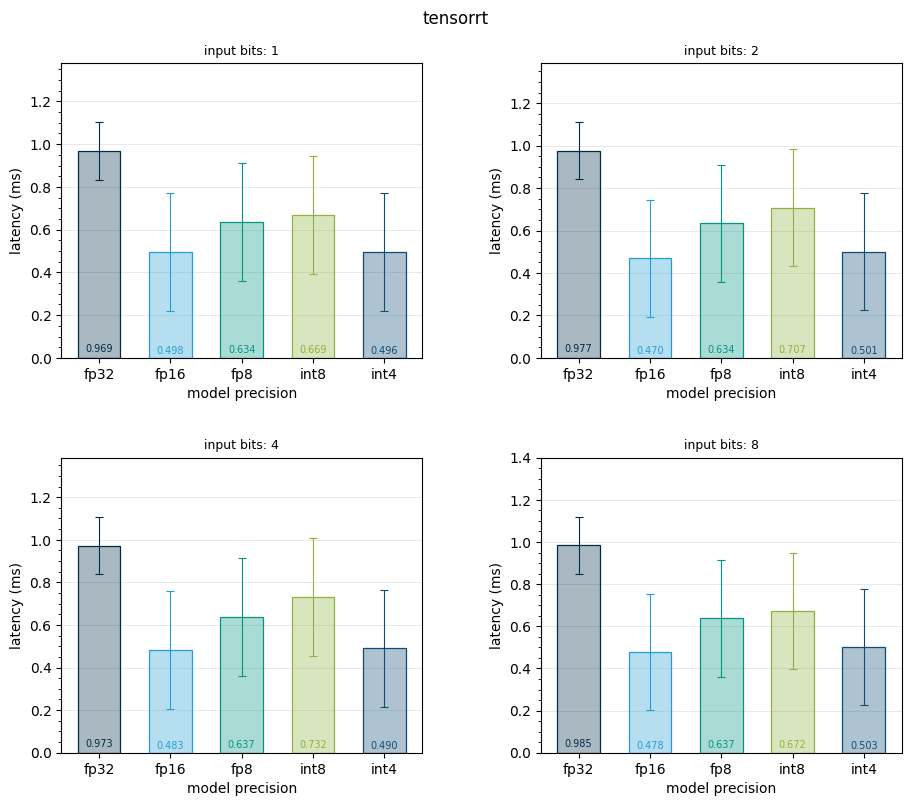

In [9]:
BACKENDS = ["pytorch", "tensorrt"]
for backend in BACKENDS:
    backend_data = table_results[table_results["backend"] == backend]
    active_bits = sorted(backend_data["input_bits"].dropna().astype(int).unique())
    n = len(active_bits)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)
    PREC_ORDER = ["fp32", "fp16", "fp8", "int8", "int4"]

    for ax, bits in zip(ax_flat, active_bits):
        grp = (
            backend_data[backend_data["input_bits"] == bits]
            .dropna(subset=["precision", "lat_ms_mean", "lat_ms_std"])
        )
        grp = grp.set_index("precision").reindex(PREC_ORDER).dropna(subset=["lat_ms_mean"]).reset_index()
        if grp.empty:
            ax.set_visible(False)
            continue

        draw_bars(ax, grp, x_col="precision",
                  y_col="lat_ms_mean", yerr_col="lat_ms_std",
                  palette=PREC_PALETTE)
        ax.set_xlabel("model precision")
        ax.set_ylabel("latency (ms)")
        ax.set_title(f"input bits: {bits}", fontsize=9)

    plt.show()


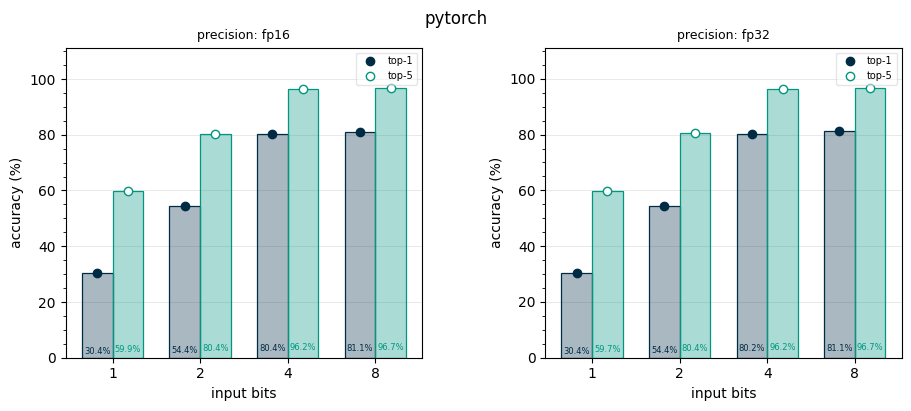

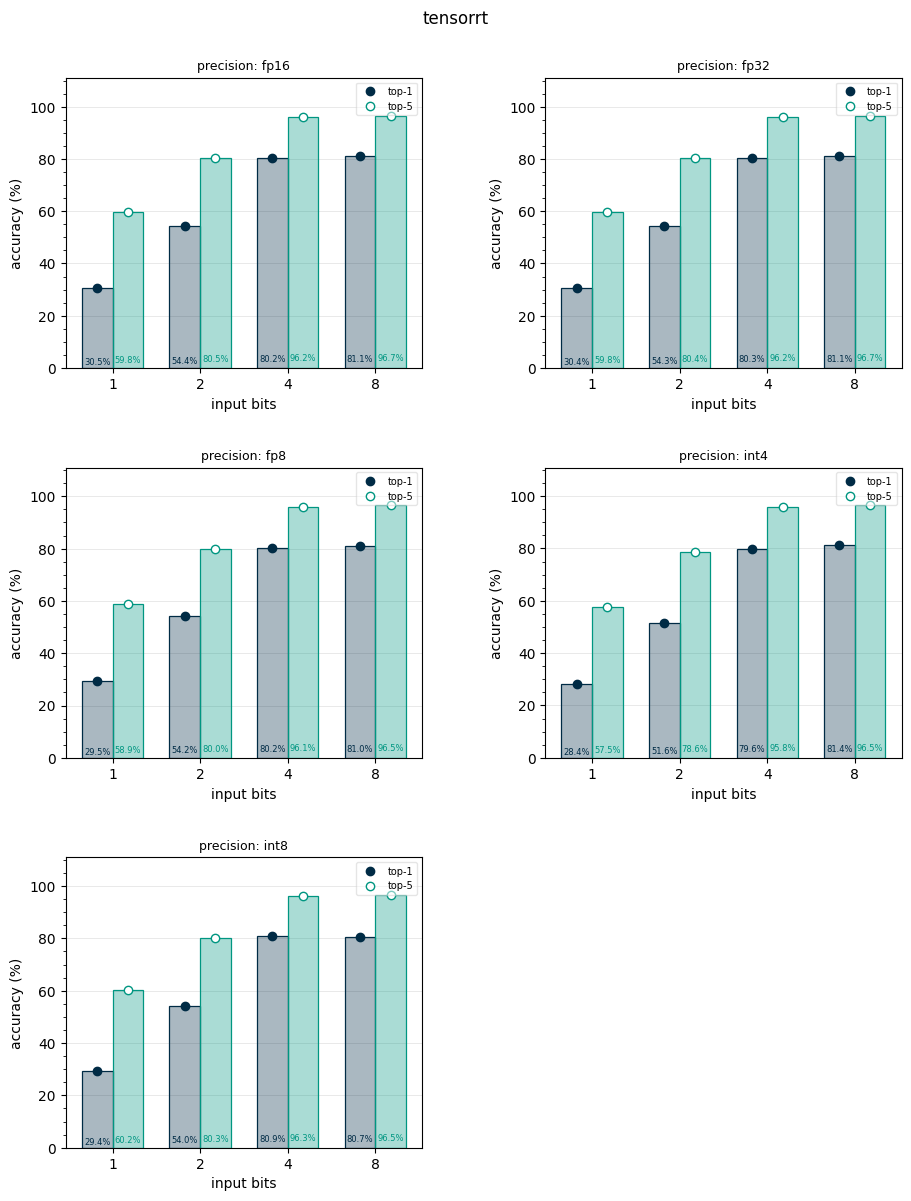

In [10]:
BACKENDS = ["pytorch", "tensorrt"]
for backend in BACKENDS:
    backend_data = table_results[table_results["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = (
            backend_data[backend_data["precision"] == prec]
            .sort_values("input_bits")
            .dropna(subset=["input_bits", "top1_mean", "top5_mean"])
        )
        if grp.empty:
            ax.set_visible(False)
            continue

        bits  = grp["input_bits"].astype(int).tolist()
        x_pos = np.arange(len(bits))

        width = 0.35
        ax.bar(x_pos - width/2, grp["top1_mean"], width=width,
               color="#002B4555", edgecolor="#002B45", linewidth=0.9, zorder=2)
        ax.bar(x_pos + width/2, grp["top5_mean"], width=width,
               color="#00968155", edgecolor="#009681", linewidth=0.9, zorder=2)

        ax.plot(x_pos - width/2, grp["top1_mean"], color="#002B45",
                marker="o", linestyle="none", markersize=6, label="top-1", zorder=3)
        ax.plot(x_pos + width/2, grp["top5_mean"], color="#009681",
                marker="o", linestyle="none", markersize=6,
                markerfacecolor="white", label="top-5", zorder=3)

        for xi, (_, row) in enumerate(grp.iterrows()):
            ax.text(xi - width/2, row["top1_mean"] * 0.02, f"{row['top1_mean']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#002B45", zorder=4)
            ax.text(xi + width/2, row["top5_mean"] * 0.02, f"{row['top5_mean']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#009681", zorder=4)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(b) for b in bits])
        ax.set_xlabel("input bits")
        ax.set_ylabel("accuracy (%)")
        ax.set_title(f"precision: {prec}", fontsize=9)
        ax.set_ylim(0, grp[["top1_mean", "top5_mean"]].max().max() * 1.15)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
        ax.legend(fontsize=7, framealpha=0.5)

    plt.show()

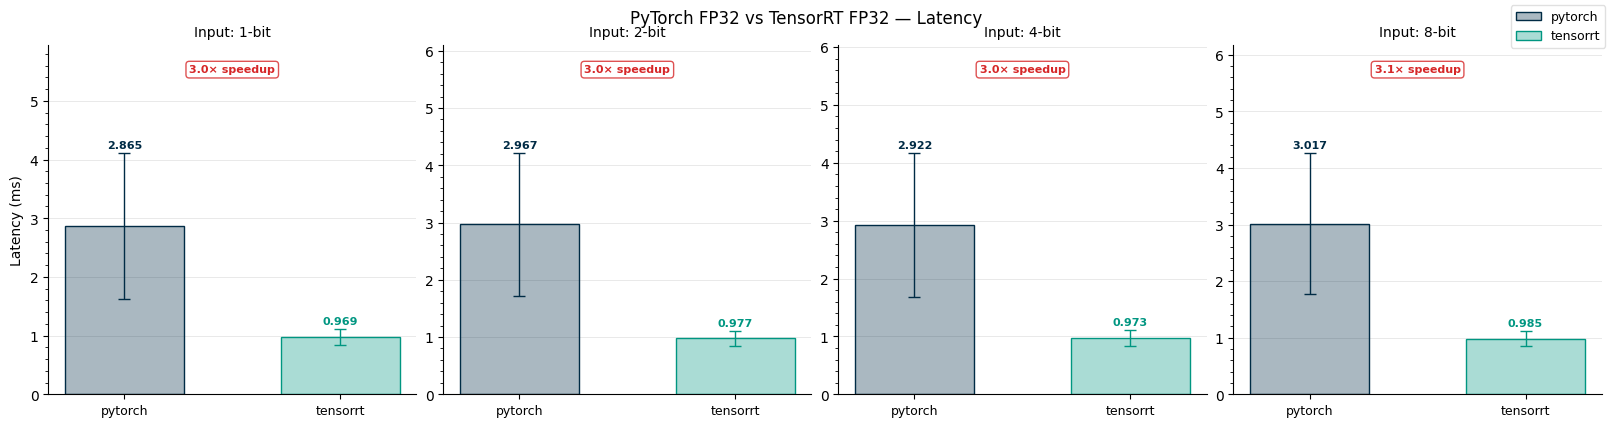

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

table_results = pd.read_csv("/home/pf4636/code/resnet/quantized_resnets/results/table_results.csv")

# Filter to only pytorch fp32 and tensorrt fp32
mask = (table_results["precision"] == "fp32") & (table_results["backend"].isin(["pytorch", "tensorrt"]))
fp32_data = table_results[mask].copy()
fp32_data["input_bits"] = fp32_data["input_bits"].astype(int)

active_bits = sorted(fp32_data["input_bits"].unique())

BACKEND_PALETTE = {
    "pytorch":  "#002B45",
    "tensorrt": "#009681",
}

fig, axes = plt.subplots(1, len(active_bits), figsize=(4 * len(active_bits), 4),
                         constrained_layout=True, sharey=False)
fig.suptitle("PyTorch FP32 vs TensorRT FP32 — Latency", fontsize=12, y=1.03)

for ax, bits in zip(axes, active_bits):
    grp = fp32_data[fp32_data["input_bits"] == bits].sort_values("backend")
    x_pos = np.arange(len(grp))

    for xi, (_, row) in enumerate(grp.iterrows()):
        color = BACKEND_PALETTE[row["backend"]]
        ax.bar(xi, row["lat_ms_mean"], width=0.55,
               color=color + "55", edgecolor=color, linewidth=1.0, zorder=2)
        ax.errorbar(xi, row["lat_ms_mean"], yerr=row["lat_ms_std"],
                    fmt="none", ecolor=color, capsize=4, capthick=1.0,
                    elinewidth=1.0, zorder=3)
        ax.text(xi, row["lat_ms_mean"] + row["lat_ms_std"] + 0.05,
                f"{row['lat_ms_mean']:.3f}",
                ha="center", va="bottom", fontsize=8, color=color, fontweight="bold")

    speedup = grp[grp["backend"] == "pytorch"]["lat_ms_mean"].values[0] / \
              grp[grp["backend"] == "tensorrt"]["lat_ms_mean"].values[0]
    ax.text(0.5, 0.92, f"{speedup:.1f}× speedup",
            transform=ax.transAxes, ha="center", fontsize=8,
            color="#D62728", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#D62728", alpha=0.8))

    ax.set_xticks(x_pos)
    ax.set_xticklabels(grp["backend"].tolist(), fontsize=9)
    ax.set_title(f"Input: {bits}-bit", fontsize=10)
    ax.set_ylabel("Latency (ms)" if bits == active_bits[0] else "")
    ax.set_ylim(0, (grp["lat_ms_mean"] + grp["lat_ms_std"]).max() * 1.45)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c + "55", edgecolor=c, linewidth=1.0, label=b)
           for b, c in BACKEND_PALETTE.items()]
fig.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.6)

plt.show()


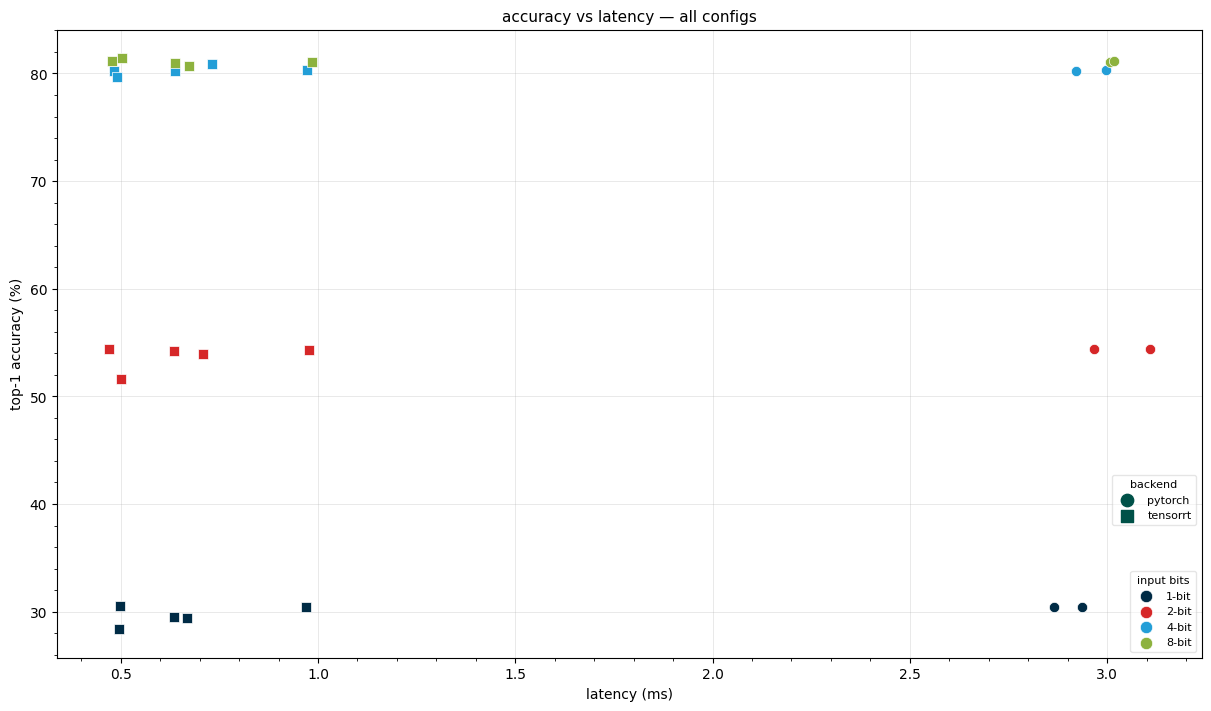

In [12]:
BACKEND_MARKERS = {
    "pytorch":  "o",
    "tensorrt": "s",
}

SCATTER_BIT_PALETTE = {
    1: "#002B45",   # Deep Navy
    2: "#D62728",   # keeping a vivid red for max contrast
    4: "#239ED7",   # Bright Sky Blue
    8: "#8DB23E",   # Olive/Lime Green
}

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for backend, bgrp in table_results.groupby("backend"):
    marker = BACKEND_MARKERS.get(backend, "o")
    for _, row in bgrp.iterrows():
        bits  = int(row["input_bits"])
        color = SCATTER_BIT_PALETTE.get(bits, "#7f7f7f")
        ax.scatter(row["lat_ms_mean"], row["top1_mean"],
                   color=color, marker=marker, s=55, edgecolors="white",
                   linewidths=0.5, zorder=3)

ax.set_xlabel("latency (ms)")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — all configs", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

legend_kw = dict(fontsize=8, title_fontsize=8, framealpha=0.5,
                 loc="lower right", markerscale=1.2)

bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=55, edgecolors="white",
                linewidths=0.5, label=f"{b}-bit")
    for b, c in SCATTER_BIT_PALETTE.items()
    if b in table_results["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits", **legend_kw)
ax.add_artist(legend1)

backend_handles = [
    plt.scatter([], [], color="#005148", marker=m, s=55, label=b)
    for b, m in BACKEND_MARKERS.items()
]
ax.legend(handles=backend_handles, title="backend",
          bbox_to_anchor=(1, 0.3), loc="upper right",
          fontsize=8, title_fontsize=8, framealpha=0.5, markerscale=1.2)

plt.show()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


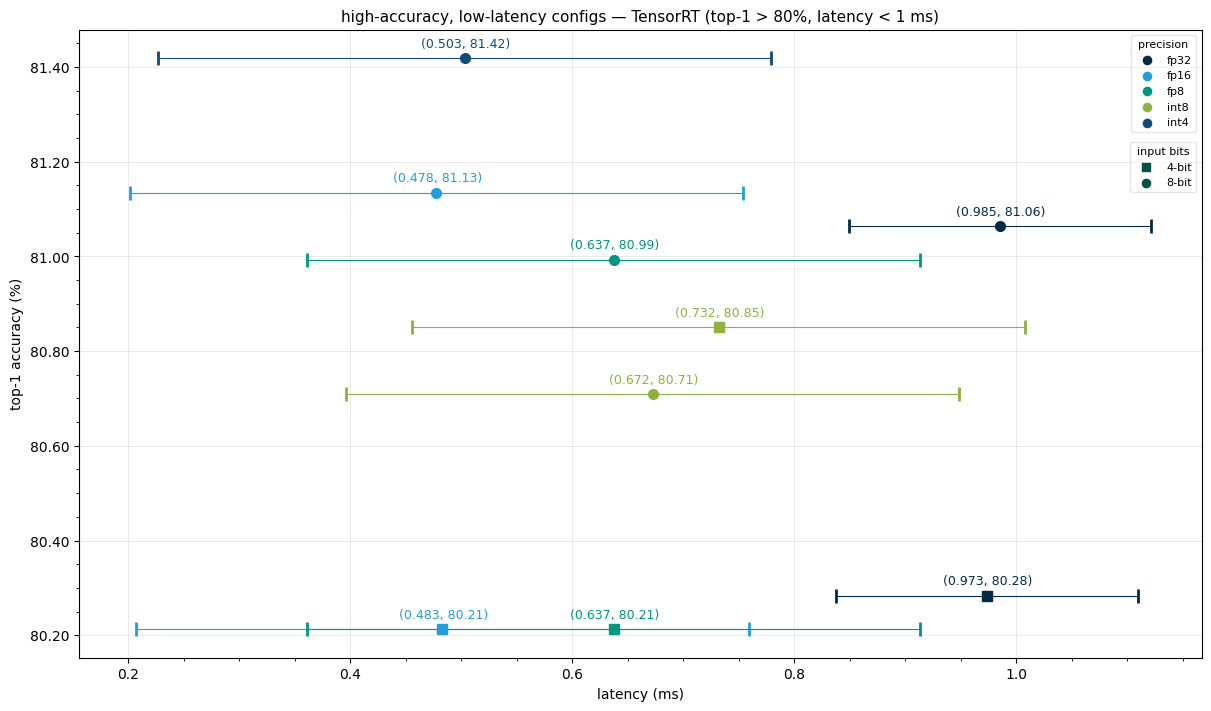

In [13]:
from adjustText import adjust_text

BIT_MARKERS = {4: "s", 8: "o"}

zoom_data = table_results[
    (table_results["backend"] == "tensorrt") &
    (table_results["input_bits"].isin([4, 8])) &
    (table_results["top1_mean"] > 80) &
    (table_results["lat_ms_mean"] < 1)
]

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

texts = []
for _, row in zoom_data.iterrows():
    color = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    marker = BIT_MARKERS.get(int(row["input_bits"]), "o")
    xerr_lo = min(row["lat_ms_std"], row["lat_ms_mean"])
    ax.errorbar(row["lat_ms_mean"], row["top1_mean"],
                xerr=[[xerr_lo], [row["lat_ms_std"]]],
                fmt=marker, color=color, markersize=7,
                elinewidth=0.8, capsize=5, capthick=2.0)
    texts.append(ax.text(
        row["lat_ms_mean"], row["top1_mean"] + 0.01,
        f"({row['lat_ms_mean']:.3f}, {row['top1_mean']:.2f})",
        fontsize=9, color=color, ha="center", va="bottom",
    ))

ax.set_xlabel("latency (ms)")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("high-accuracy, low-latency configs — TensorRT (top-1 > 80%, latency < 1 ms)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5)

adjust_text(
    texts, ax=ax,
    only_move={"text": "y", "static": "y", "explode": "y"},
    expand_points=(1.4, 2.0),
    expand_text=(1.2, 1.6),
    arrowprops=dict(arrowstyle="-", color="#A9BCC6", lw=0.5, alpha=0.6),
)

legend_kw = dict(fontsize=8, title_fontsize=8, framealpha=0.5)

prec_handles = [
    plt.scatter([], [], color=PREC_PALETTE[p], marker="o", s=35, label=p)
    for p in PREC_PALETTE if p in zoom_data["precision"].values
]
legend1 = ax.legend(handles=prec_handles, title="precision",
                    loc="upper right", **legend_kw)
ax.add_artist(legend1)

bits_handles = [
    plt.scatter([], [], color="#005148", marker=m, s=35, label=f"{b}-bit")
    for b, m in BIT_MARKERS.items()
]
ax.legend(handles=bits_handles, title="input bits",
          bbox_to_anchor=(1, 0.83), loc="upper right", **legend_kw)

plt.show()


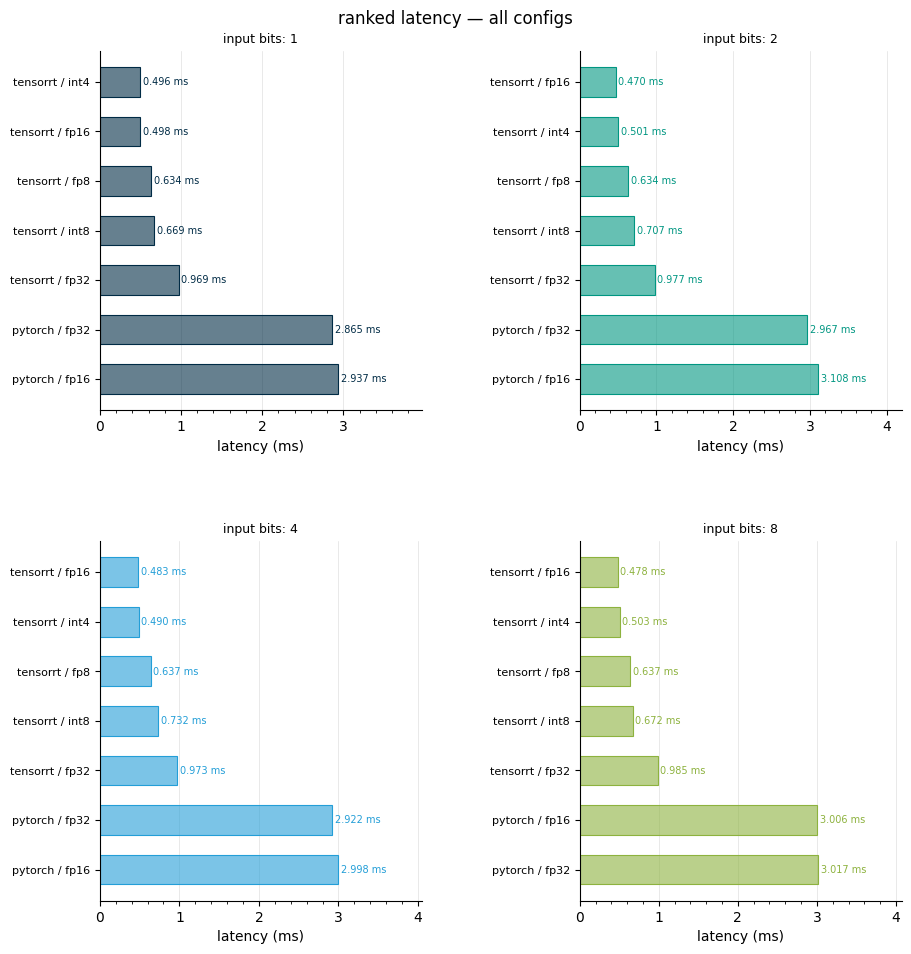

In [14]:
ranked = (
    table_results
    .sort_values("lat_ms_mean")
    .reset_index(drop=True)
)
ranked["label"] = ranked["backend"] + " / " + ranked["precision"]
ranked["input_bits"] = ranked["input_bits"].astype(int)

active_bits = sorted(ranked["input_bits"].unique())
n = len(active_bits)
nrows = math.ceil(n / COLS)

fig, axes = plt.subplots(
    nrows, COLS,
    figsize=(4.5 * COLS, 0),
    constrained_layout=True,
    squeeze=False,
)

max_bars = ranked.groupby("input_bits").size().max()
fig.set_size_inches(4.5 * COLS, max_bars * 0.55 * nrows + 1.5)

fig.suptitle("ranked latency — all configs", fontsize=12,
             x=0.5, ha="center", y=1.02)
fig.set_constrained_layout_pads(wspace=0.15, hspace=0.15)

ax_flat = axes.flatten()
for idx in range(n, len(ax_flat)):
    ax_flat[idx].set_visible(False)

for ax, bits in zip(ax_flat, active_bits):
    grp = ranked[ranked["input_bits"] == bits].sort_values("lat_ms_mean").reset_index(drop=True)

    if grp.empty:
        ax.set_visible(False)
        continue

    color = BIT_PALETTE.get(bits, "#7f7f7f")
    y_pos = np.arange(len(grp))

    ax.barh(y_pos, grp["lat_ms_mean"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.6, zorder=2)

    for yi, (_, row) in enumerate(grp.iterrows()):
        ax.text(row["lat_ms_mean"] + ax.get_xlim()[1] * 0.01, yi,
                f"{row['lat_ms_mean']:.3f} ms",
                ha="left", va="center", fontsize=7, color=color, zorder=4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(grp["label"], fontsize=8)
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.set_xlabel("latency (ms)")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlim(0, grp["lat_ms_mean"].max() * 1.35)

plt.show()


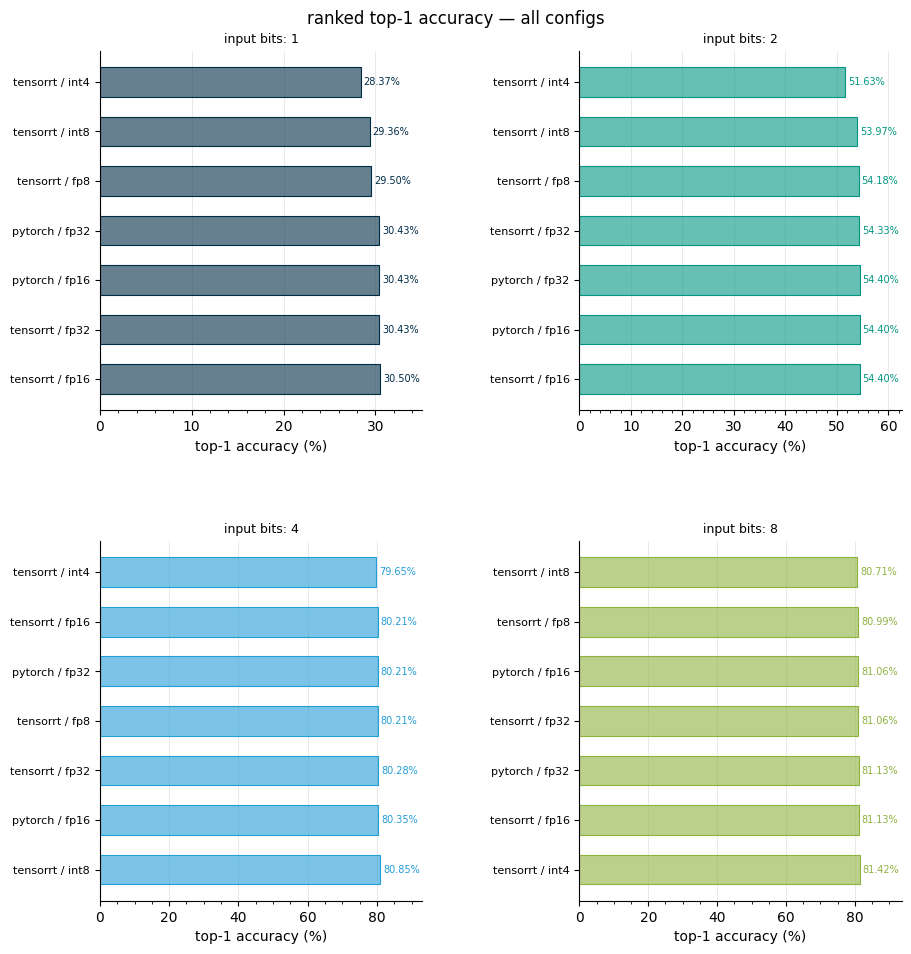

In [15]:
ranked_acc = (
    table_results
    .sort_values("top1_mean", ascending=False)
    .reset_index(drop=True)
)
ranked_acc["label"] = ranked_acc["backend"] + " / " + ranked_acc["precision"]
ranked_acc["input_bits"] = ranked_acc["input_bits"].astype(int)

active_bits = sorted(ranked_acc["input_bits"].unique())
n = len(active_bits)
nrows = math.ceil(n / COLS)

fig, axes = plt.subplots(
    nrows, COLS,
    figsize=(4.5 * COLS, 0),
    constrained_layout=True,
    squeeze=False,
)

max_bars = ranked_acc.groupby("input_bits").size().max()
fig.set_size_inches(4.5 * COLS, max_bars * 0.55 * nrows + 1.5)

fig.suptitle("ranked top-1 accuracy — all configs", fontsize=12,
             x=0.5, ha="center", y=1.02)
fig.set_constrained_layout_pads(wspace=0.15, hspace=0.15)

ax_flat = axes.flatten()
for idx in range(n, len(ax_flat)):
    ax_flat[idx].set_visible(False)

for ax, bits in zip(ax_flat, active_bits):
    grp = ranked_acc[ranked_acc["input_bits"] == bits].sort_values("top1_mean").reset_index(drop=True)

    if grp.empty:
        ax.set_visible(False)
        continue

    color = BIT_PALETTE.get(bits, "#7f7f7f")
    y_pos = np.arange(len(grp))

    ax.barh(y_pos, grp["top1_mean"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.6, zorder=2)

    for yi, (_, row) in enumerate(grp.iterrows()):
        ax.text(row["top1_mean"] + ax.get_xlim()[1] * 0.01, yi,
                f"{row['top1_mean']:.2f}%",
                ha="left", va="center", fontsize=7, color=color, zorder=4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(grp["label"], fontsize=8)
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.set_xlabel("top-1 accuracy (%)")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlim(0, grp["top1_mean"].max() * 1.15)

plt.show()


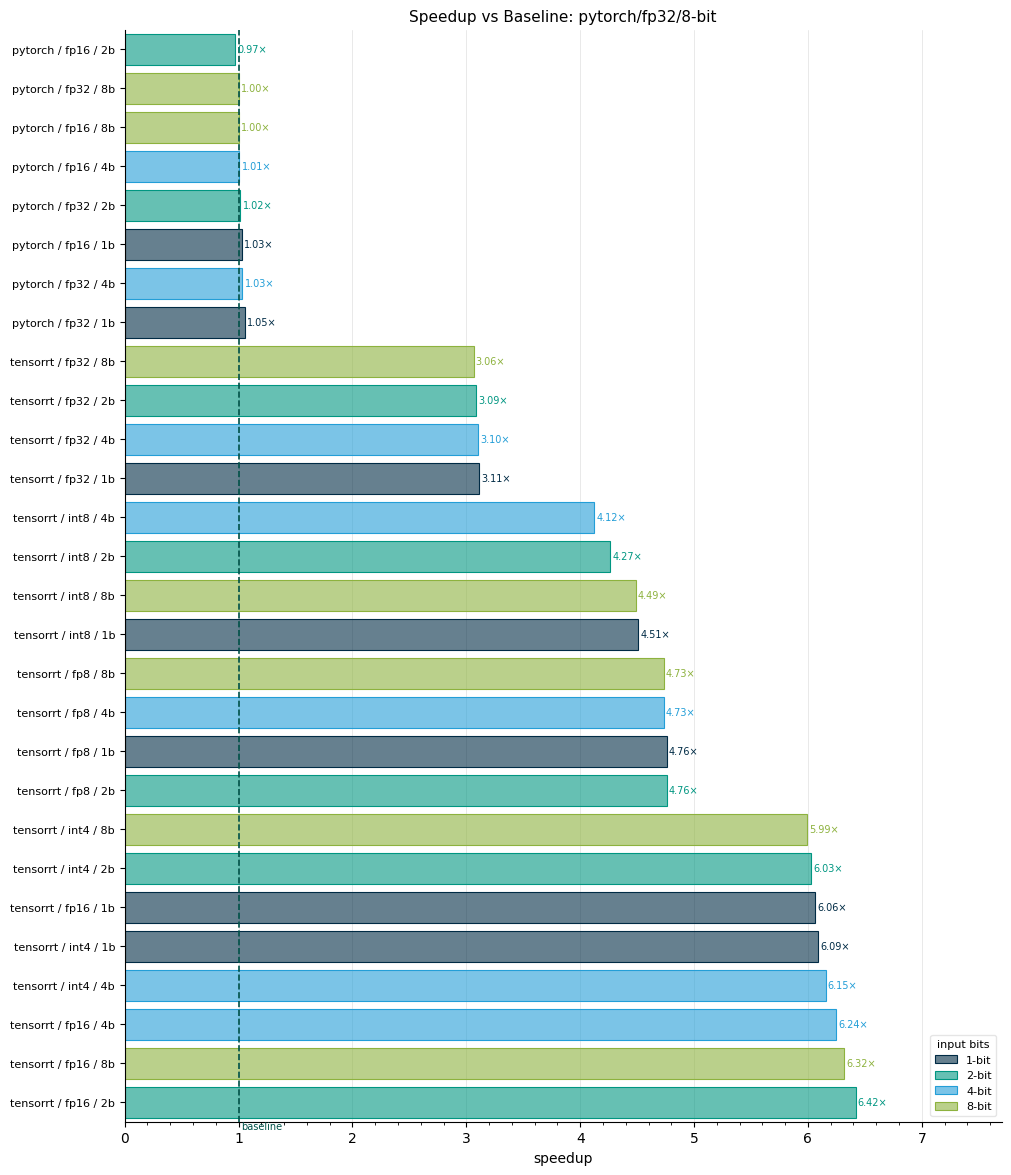

In [16]:
baseline = table_results[
    (table_results["backend"] == "pytorch") &
    (table_results["precision"] == "fp32") &
    (table_results["input_bits"] == 8)
]["lat_ms_mean"].values[0]

speedup = table_results.copy()
speedup["speedup"]    = baseline / speedup["lat_ms_mean"]
speedup["label"]      = (speedup["backend"] + " / " +
                         speedup["precision"] + " / " +
                         speedup["input_bits"].astype(int).astype(str) + "b")
speedup["input_bits"] = speedup["input_bits"].astype(int)

speedup = speedup.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup.iterrows()):
    bits  = int(row["input_bits"])
    color = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}×",
            ha="left", va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3, label="baseline")
ax.text(1.02, len(speedup) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(speedup)))
ax.set_yticklabels(speedup["label"], fontsize=8)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline: pytorch/fp32/8-bit", fontsize=11)
ax.set_xlim(0, speedup["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_bits = sorted(b for b in BIT_PALETTE if b in speedup["input_bits"].values)
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=BIT_PALETTE[b] + "99",
                  edgecolor=BIT_PALETTE[b], linewidth=0.8,
                  label=f"{b}-bit")
    for b in present_bits
]
ax.legend(handles=handles, title="input bits", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

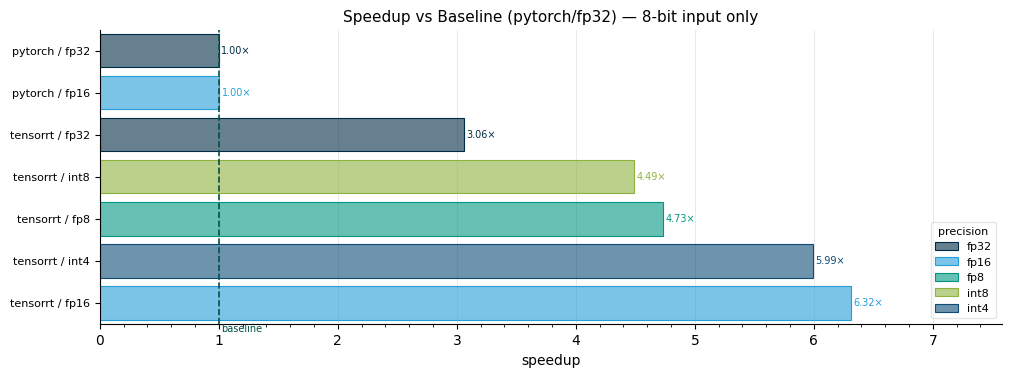

In [17]:
baseline = table_results[
    (table_results["backend"] == "pytorch") &
    (table_results["precision"] == "fp32") &
    (table_results["input_bits"] == 8)
]["lat_ms_mean"].values[0]

speedup = table_results[table_results["input_bits"] == 8].copy()
speedup["speedup"]    = baseline / speedup["lat_ms_mean"]
speedup["label"]      = speedup["backend"] + " / " + speedup["precision"]

speedup = speedup.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup.iterrows()):
    color = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}×",
            ha="left", va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3, label="baseline")
ax.text(1.02, len(speedup) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(speedup)))
ax.set_yticklabels(speedup["label"], fontsize=8)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline (pytorch/fp32) — 8-bit input only", fontsize=11)
ax.set_xlim(0, speedup["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_precs = [p for p in PREC_PALETTE if p in speedup["precision"].values]
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=PREC_PALETTE[p] + "99",
                  edgecolor=PREC_PALETTE[p], linewidth=0.8,
                  label=p)
    for p in present_precs
]
ax.legend(handles=handles, title="precision", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()


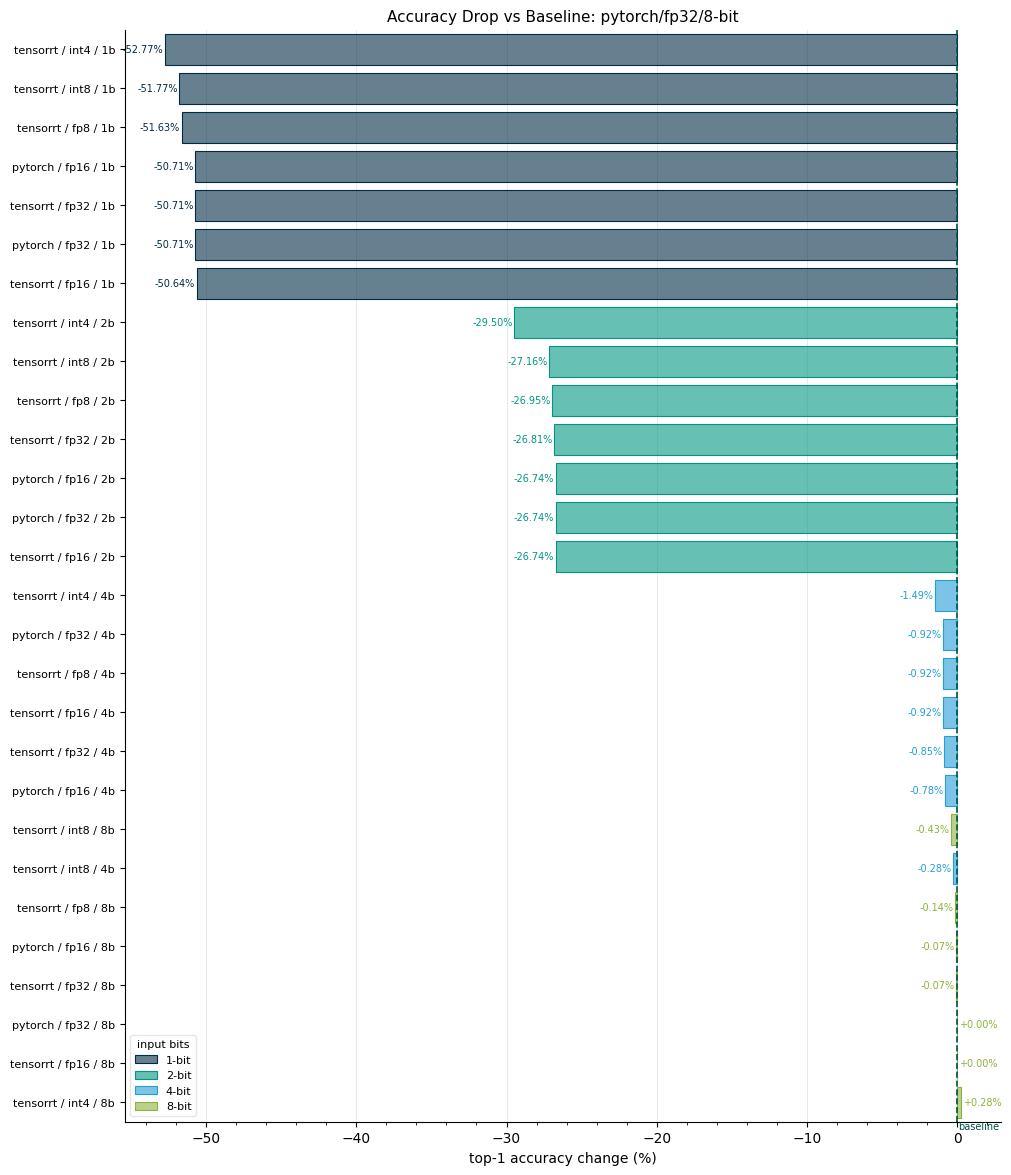

In [18]:
baseline_top1 = table_results[
    (table_results["backend"] == "pytorch") &
    (table_results["precision"] == "fp32") &
    (table_results["input_bits"] == 8)
]["top1_mean"].values[0]

acc = table_results.copy()
acc["acc_drop"]    = acc["top1_mean"] - baseline_top1
acc["label"]       = (acc["backend"] + " / " +
                      acc["precision"] + " / " +
                      acc["input_bits"].astype(int).astype(str) + "b")
acc["input_bits"]  = acc["input_bits"].astype(int)

acc = acc.sort_values("acc_drop", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(acc) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(acc.iterrows()):
    bits  = int(row["input_bits"])
    color = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.barh(yi, row["acc_drop"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    sign = "+" if row["acc_drop"] >= 0 else ""
    offset = 0.1 if row["acc_drop"] >= 0 else -0.1
    ax.text(row["acc_drop"] + offset, yi,
            f"{sign}{row['acc_drop']:.2f}%",
            ha="left" if row["acc_drop"] >= 0 else "right",
            va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=0.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(0.1, len(acc) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(acc)))
ax.set_yticklabels(acc["label"], fontsize=8)
ax.set_xlabel("top-1 accuracy change (%)")
ax.set_title("Accuracy Drop vs Baseline: pytorch/fp32/8-bit", fontsize=11)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(acc) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_bits = sorted(b for b in BIT_PALETTE if b in acc["input_bits"].values)
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=BIT_PALETTE[b] + "99",
                  edgecolor=BIT_PALETTE[b], linewidth=0.8,
                  label=f"{b}-bit")
    for b in present_bits
]
ax.legend(handles=handles, title="input bits", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower left")

plt.show()

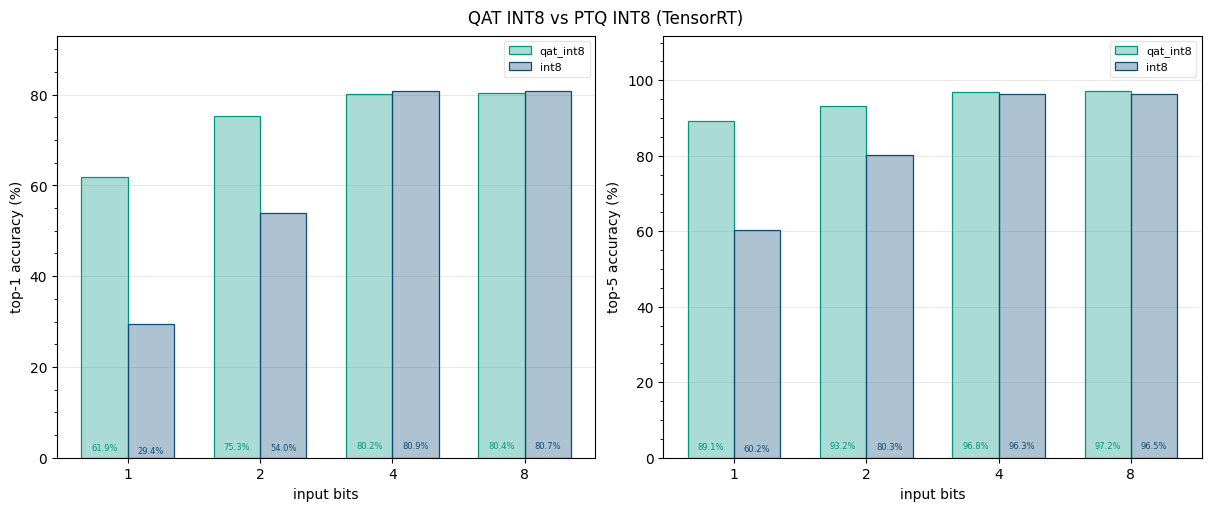

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle("QAT INT8 vs PTQ INT8 (TensorRT)", fontsize=12)

for ax, metric, ylabel in [(ax1, "top1", "top-1 accuracy (%)"),
                            (ax2, "top5", "top-5 accuracy (%)")]:
    width = 0.35
    bits_list = sorted(table_qat["input_bits"].unique())
    x_pos = np.arange(len(bits_list))

    for i, prec in enumerate(["qat_int8", "int8"]):
        grp = table_qat[table_qat["precision"] == prec].sort_values("input_bits")
        offset = -width / 2 if i == 0 else width / 2
        color = QAT_PALETTE[prec]
        ax.bar(x_pos + offset, grp[metric], width=width,
               color=color + "55", edgecolor=color,
               linewidth=0.9, zorder=2, label=prec)
        for xi, (_, row) in enumerate(grp.iterrows()):
            ax.text(xi + offset, row[metric] * 0.02, f"{row[metric]:.1f}%",
                    ha="center", va="bottom", fontsize=6, color=color, zorder=4)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(b) for b in bits_list])
    ax.set_xlabel("input bits")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, table_qat[metric].max() * 1.15)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
    ax.legend(fontsize=8, framealpha=0.5)

plt.show()